In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import cv2
import random
import torch
from mtrain.disk import DiskImage, DiskBooleanMask
from mtrain.utils import mkdir

In [3]:
DS = Path("../../datasets/")
BASE = DS / "test-samples"
NEG_MASKING_V1 = BASE / "neg-masking" / "V1"
ROCKS = NEG_MASKING_V1 / "rocks"
SAMPLES_MAPILLARY = NEG_MASKING_V1 / "samples_mapillary"
ROCKS_TXT_FILE = ROCKS / "clip_query_res.txt"
ROCKS_DATA_DIR = mkdir(ROCKS / "data")
ROCKS_CVAT_DIR = mkdir(ROCKS / "cvat")
ROCKS_DS_DIR = ROCKS / "classification" / "crop_level"

SAMPLES_MAPILLARY.exists(), ROCKS.exists()

(True, True)

# convert 255 to 1 masks if needed

Some masks were accidentally using 255 for foreground instead of 1, you can use this to change them

In [4]:
from tqdm import tqdm
import shutil


def show_masks_unique(dirs, fname):
    uq = set()
    for d in tqdm(dirs):
        uq.add(tuple(np.unique(DiskBooleanMask.load(d / fname))))
    return uq


def fix_masks_unique(dirs):
    for d in tqdm(dirs):
        mask = DiskBooleanMask.load(d / "mask.png")
        mask = mask.astype(bool).astype(np.uint8)
        DiskBooleanMask.save(mask, d / "m1.png")


def make_m1_mask(dirs):
    for d in tqdm(dirs):
        shutil.move(d / "m1.png", d / "mask.png")


def verify_m1_and_masks(dirs):
    for d in tqdm(dirs):
        mask, m1 = d / "mask.png", d / "m1.png"
        mask, m1 = DiskBooleanMask.load(mask), DiskBooleanMask.load(m1)
        assert np.all(mask.astype(bool) == m1.astype(bool))
    print("all good")

# Model training

## Dataset

In [4]:
from torchvision.transforms import v2
from torchvision import tv_tensors
from PIL import Image


def _is_valid_dir(direc: Path):
    valid = (
        direc.is_dir()
        and (direc / "image.jpg").exists()
        and (direc / "mask.png").exists()
    )
    return valid


def get_ds_dirs(ds_root, labels):
    res = []
    for label in labels:
        cls_root = ds_root / label
        print(cls_root.name)
        if not cls_root.is_dir():
            continue
        for d in cls_root.glob("*"):
            if _is_valid_dir(d):
                res.append(d)
    random.shuffle(res)
    return res


def _label_func(d: Path):
    return Path(d).parent.name


def _validate_labels_in_dirs(dirs, label_by_idx):
    for d in dirs:
        label = _label_func(d)
        if label not in label_by_idx:
            raise Exception(
                f"Label={label} not found for directory={d}. label_by_index={label_by_idx}"
            )


class MaskClassificationDataset(torch.utils.data.Dataset):
    RESIZE_SIZE = (220, 220)
    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD = [0.229, 0.224, 0.225]

    def __init__(
        self,
        dirs: list[Path | str],
        norm_stats: tuple[list[float], list[float]],
        labels: list[
            str
        ],  # make sure these are always in the same order, new labels should be appended
    ):
        self.mean = torch.tensor(norm_stats[0])
        self.std = torch.tensor(norm_stats[1])
        self.dirs = [d for d in map(Path, dirs) if _is_valid_dir(d)]
        self.labels = labels
        self.label_by_idx = {label: i for i, label in enumerate(self.labels)}
        self.tfms = v2.Compose(
            [
                v2.Resize(200, antialias=True),
                v2.RandomCrop(130),
                v2.RandomHorizontalFlip(p=0.5),
                v2.ToDtype(torch.float32, scale=True),
                v2.Normalize(mean=self.IMAGENET_MEAN, std=self.IMAGENET_STD),
                v2.ToPureTensor(),
            ]
        )
        _validate_labels_in_dirs(self.dirs, self.label_by_idx)

    def __len__(self):
        return len(self.dirs)

    def __getitem__(self, index):
        d = self.dirs[index]

        # load individual as tensors
        img = tv_tensors.Image(Image.open(d / "image.jpg").convert("RGB"))
        mask = tv_tensors.Mask(Image.open(d / "mask.png").convert("L"))

        # tfms then combine
        t_img, t_mask = self.tfms([img, mask])
        combined = torch.cat([t_img, t_mask], dim=0)

        # label tensor
        label = _label_func(d)
        label_idx = self.label_by_idx[label]
        label_tensor = torch.Tensor([label_idx]).squeeze()

        return (combined, label_tensor)

In [24]:
from sklearn.model_selection import train_test_split

LABELS = ["trash", "other"]

dirs = get_ds_dirs(ROCKS_DS_DIR, LABELS)


labels = [_label_func(d) for d in dirs]
train_dirs, valid_dirs = train_test_split(
    dirs, test_size=0.2, stratify=labels, random_state=42
)

trash
other


In [25]:
from fastai.vision.all import imagenet_stats

train_ds = MaskClassificationDataset(train_dirs, imagenet_stats, LABELS)
valid_ds = MaskClassificationDataset(valid_dirs, imagenet_stats, LABELS)

### Visualise single tensors

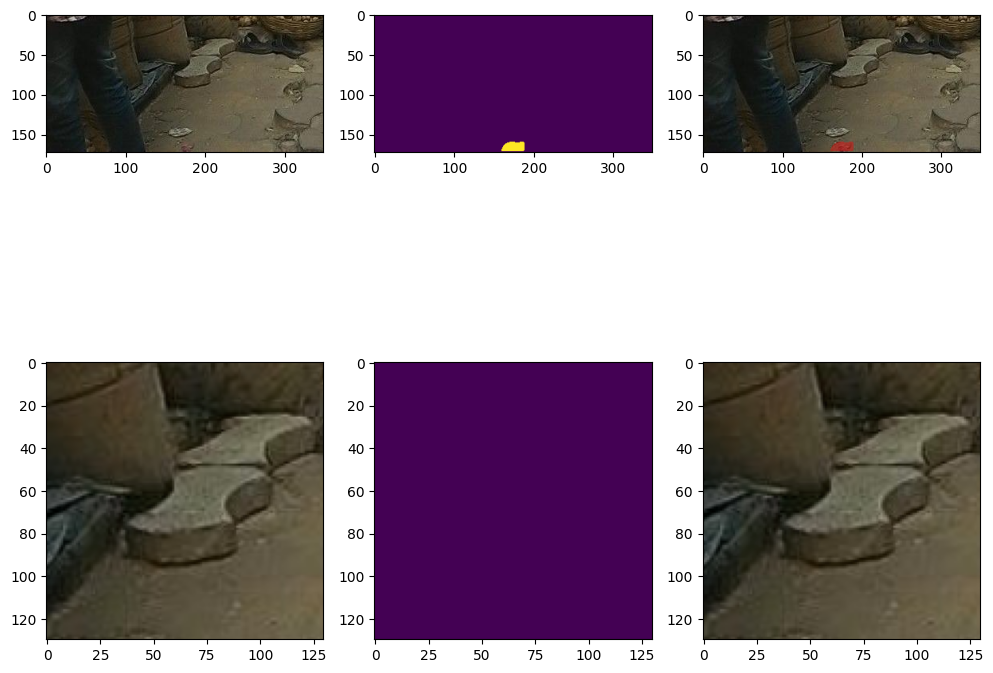

In [10]:
from mtrain.smallnet.unet.extract.draw import overlay_mask_on_img
from mtrain.utils import show


def denormalize(tf_img):
    std = torch.Tensor(MaskClassificationDataset.IMAGENET_STD)
    mean = torch.Tensor(MaskClassificationDataset.IMAGENET_MEAN)
    tf_img = (tf_img * std + mean).clamp(0, 1)
    return tf_img


idx = 6
orig_img, orig_mask = (
    plt.imread(train_dirs[idx] / "image.jpg"),
    plt.imread(train_dirs[idx] / "mask.png"),
)
data_point = train_ds[idx]
tf_img, tf_mask = data_point[0][:3].permute(1, 2, 0), data_point[0][3]
tf_img = denormalize(tf_img)
tf_img, tf_mask = (tf_img.numpy() * 255).astype(np.uint8), tf_mask.numpy().astype(bool)
show(
    [
        orig_img,
        orig_mask,
        overlay_mask_on_img(orig_img, orig_mask.astype(bool)),
        tf_img,
        tf_mask,
        overlay_mask_on_img(tf_img, tf_mask),
    ],
    (10, 10),
    ncols=3,
)

# Model train

- Current status: very imbalanced, need more points for trash and unknown

In [26]:
from fastai.data.core import DataLoaders, default_device
from fastai.vision.all import (
    vision_learner,
    mobilenet_v3_small,
    accuracy,
    RocAuc,
    F1Score,
    CrossEntropyLossFlat,
    ProgressCallback,
)

dls = DataLoaders.from_dsets(train_ds, valid_ds, device=default_device())

In [27]:
from collections import defaultdict

def get_label_stats(dirs):
    counts = defaultdict(lambda: 0)
    for d in dirs:
        counts[_label_func(d)] += 1
    return {
        "counts": dict(counts)
    }

In [28]:
LABELS, train_ds.label_by_idx, get_label_stats(dirs)

(['trash', 'other'],
 {'trash': 0, 'other': 1},
 {'counts': {'other': 4662, 'trash': 1058}})

In [29]:
counts = torch.tensor([1058, 4662], dtype=torch.float32)
weights = 1 / counts
weights = weights / weights.sum()  # normalize
weights = weights.to(default_device())

learn = vision_learner(
    dls,
    mobilenet_v3_small,
    n_in=4,
    metrics=[accuracy, F1Score(average="macro")],
    loss_func=CrossEntropyLossFlat(weight=weights),
    n_out=len(LABELS),
    normalize=False,
)
learn = learn.remove_cb(ProgressCallback)

/Users/hariomnarang/Desktop/personal/roads/mtrain/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/hariomnarang/Desktop/personal/roads/mtrain/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [30]:
learn.fine_tune(5)

[0, 0.8694664835929871, 0.6925541162490845, 0.6748251914978027, 0.6127581048470753, '00:31']
[0, 0.658298134803772, 0.499462753534317, 0.7237762212753296, 0.6715988372093022, '00:37']
[1, 0.6373134255409241, 0.5105021595954895, 0.8330419659614563, 0.7573296757606215, '00:38']
[2, 0.5612003803253174, 0.3945468068122864, 0.8208041787147522, 0.7555695681402463, '00:33']
[3, 0.5036261081695557, 0.39431121945381165, 0.811188817024231, 0.7440238672384859, '00:38']
[4, 0.45948275923728943, 0.386682391166687, 0.8164335489273071, 0.7558129606967015, '00:43']


In [33]:
learn.fit_one_cycle(5, lr_max=slice(1e-6, 1e-4))

[0, 0.43992382287979126, 0.3807867765426636, 0.8330419659614563, 0.7688099059703087, '00:34']
[1, 0.4336373209953308, 0.3954865634441376, 0.8426573276519775, 0.7729107390987892, '00:33']
[2, 0.4510086476802826, 0.3728468418121338, 0.8347902297973633, 0.7676373519496277, '00:33']
[3, 0.4497048258781433, 0.3998631238937378, 0.8391608595848083, 0.7722732859046926, '00:33']
[4, 0.4454030692577362, 0.37301644682884216, 0.8435314893722534, 0.7805109934220611, '00:33']


SuggestedLRs(valley=3.311311274956097e-06)

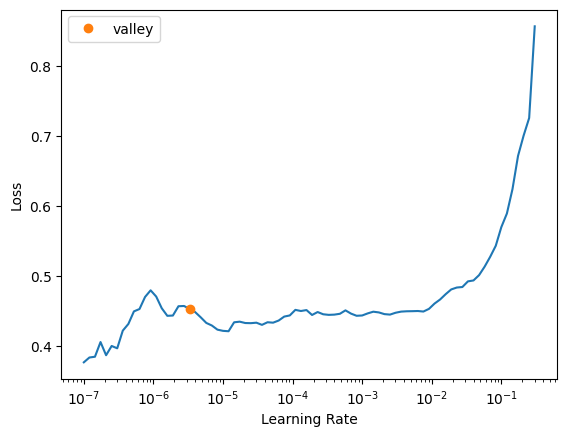

In [35]:
learn.lr_find()

In [36]:
learn.fit_one_cycle(5, lr_max=slice(1e-7, 1e-6))

[0, 0.432340145111084, 0.371951699256897, 0.8461538553237915, 0.7844725709490126, '00:35']
[1, 0.42262977361679077, 0.35774317383766174, 0.8496503233909607, 0.7876937286094698, '00:34']
[2, 0.44252610206604004, 0.40585416555404663, 0.8391608595848083, 0.7746758696285132, '00:38']
[3, 0.42819342017173767, 0.3632374703884125, 0.8470279574394226, 0.784849399953359, '00:35']
[4, 0.41776376962661743, 0.3975665867328644, 0.8356643319129944, 0.7715645246946362, '00:34']


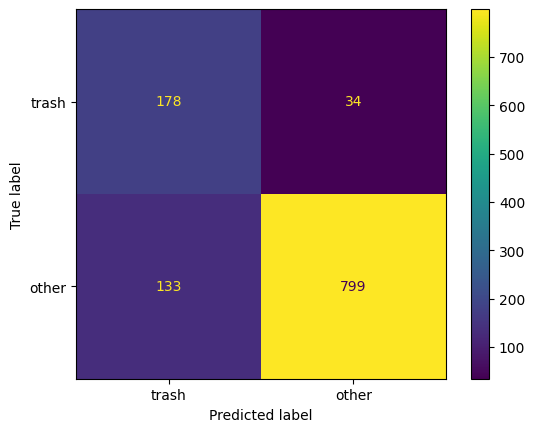

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
preds, targs = learn.get_preds(dl=dls.valid)
pred_classes = preds.argmax(dim=1)

cm = confusion_matrix(targs, pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
disp.plot()

In [43]:
model_dir = mkdir(DS / "models" / "trash_classification")
learn.save((model_dir / "mobilenet_small").resolve())

Path('/Users/hariomnarang/Desktop/personal/roads/datasets/models/trash_classification/mobilenet_small.pth')